In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

In [2]:
df = pd.read_csv('data1300.csv')
print(df['Label'].value_counts())
df.head()

Label
Fact        722
Non-Fact    616
Name: count, dtype: int64


,Doc,Label
0,There are plenty of hosting providers to choos...,Non-Fact
1,"We always want services which are the fastest,...",Non-Fact
2,Shortly - we want the best and the most reason...,Non-Fact
3,It is obvious that people want to get the best...,Non-Fact
4,You should also keep in mind that bigger price...,Non-Fact


# Handling Length Variations

In [3]:
l_df = df.copy()
l_df['doc_length'] = l_df['Doc'].astype(str).apply(lambda x: len(x.split()))
l_df.head()

,Doc,Label,doc_length
0,There are plenty of hosting providers to choos...,Non-Fact,11
1,"We always want services which are the fastest,...",Non-Fact,17
2,Shortly - we want the best and the most reason...,Non-Fact,10
3,It is obvious that people want to get the best...,Non-Fact,15
4,You should also keep in mind that bigger price...,Non-Fact,13


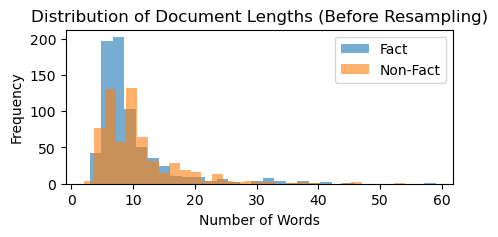

In [4]:
fact_lengths = l_df[l_df['Label'] == 'Fact']['doc_length']
nonfact_lengths = l_df[l_df['Label'] == 'Non-Fact']['doc_length']

plt.figure(figsize=(5, 2))
plt.hist(fact_lengths, bins=30, alpha=0.6, label='Fact')
plt.hist(nonfact_lengths, bins=30, alpha=0.6, label='Non-Fact')
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Document Lengths (Before Resampling)")
plt.legend()
plt.show()

In [5]:
bins = [0, 5, 10, 15, 20, 30, np.inf]
bin_labels = ['0-5', '6-10', '11-15', '16-20', '21-30', '30+']
l_df['length_bin'] = pd.cut(l_df['doc_length'], bins=bins, labels=bin_labels)

facts = l_df[l_df['Label'] == 'Fact']
non_facts = l_df[l_df['Label'] == 'Non-Fact']

resampled_facts = []
for b in bin_labels:
    fact_bin = facts[facts['length_bin'] == b]
    non_fact_bin = non_facts[non_facts['length_bin'] == b]
    target = len(non_fact_bin)
    if len(fact_bin) == 0 or target == 0:
        continue
    resampled_facts.append(
        fact_bin.sample(n=min(len(fact_bin), target), random_state=42)
    )

l_df = pd.concat(resampled_facts + [non_facts]).sample(frac=1, random_state=42).reset_index(drop=True)

print("After resampling:")
print(l_df['Label'].value_counts())

After resampling:
Label
Non-Fact    616
Fact        571
Name: count, dtype: int64


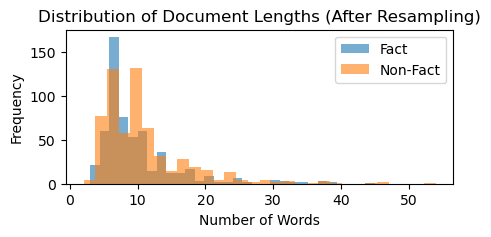

In [6]:
fact_lengths_new = l_df[l_df['Label'] == 'Fact']['doc_length']
nonfact_lengths_new = l_df[l_df['Label'] == 'Non-Fact']['doc_length']

plt.figure(figsize=(5, 2))
plt.hist(fact_lengths_new, bins=30, alpha=0.6, label='Fact')
plt.hist(nonfact_lengths_new, bins=30, alpha=0.6, label='Non-Fact')
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Document Lengths (After Resampling)")
plt.legend()
plt.show()

In [7]:
l_df = l_df.drop('doc_length', axis=1)
l_df = l_df.drop('length_bin', axis=1)
l_df.head()

,Doc,Label
0,He has acted in more than 350 films.,Fact
1,Technology is becoming more important in every...,Non-Fact
2,There is a general shift toward adopting tools...,Non-Fact
3,The Miss World organization released videos.,Fact
4,People tend to rely on tools and systems that ...,Non-Fact


In [8]:
y = l_df['Label'].map({'Fact':1, 'Non-Fact':0})

# Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(l_df, test_size=0.2, random_state=42, stratify=l_df['Label'])

y_train = train_df['Label'].map({'Fact': 1, 'Non-Fact': 0})
y_test  = test_df['Label'].map({'Fact': 1, 'Non-Fact': 0})

print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")
print(f"Train label dist:\n{y_train.value_counts()}")

Train size: 949 | Test size: 238
Train label dist:
Label
0    492
1    457
Name: count, dtype: int64


# BERT

In [10]:
# ============================================================
# BERT Fine-tuning (bert-base-uncased)
# ============================================================
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from sklearn.metrics import confusion_matrix, classification_report

BERT_MODEL  = 'bert-base-uncased'
MAX_LEN     = 128
BATCH_SIZE  = 16
EPOCHS      = 3
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels = list(texts), list(labels)
        self.tokenizer, self.max_len = tokenizer, max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }

tokenizer_bert = BertTokenizer.from_pretrained(BERT_MODEL)

train_loader = DataLoader(
    TextDataset(train_df['Doc'], y_train.values, tokenizer_bert, MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(
    TextDataset(test_df['Doc'], y_test.values, tokenizer_bert, MAX_LEN),
    batch_size=BATCH_SIZE
)

model_bert = BertForSequenceClassification.from_pretrained(BERT_MODEL, num_labels=2).to(DEVICE)
optimizer_bert = AdamW(model_bert.parameters(), lr=2e-5)

def train_epoch(model, loader, optimizer):
    model.train()
    for batch in loader:
        optimizer.zero_grad()
        out = model(
            input_ids=batch['input_ids'].to(DEVICE),
            attention_mask=batch['attention_mask'].to(DEVICE),
            labels=batch['label'].to(DEVICE)
        )
        out.loss.backward()
        optimizer.step()

def evaluate(model, loader):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for batch in loader:
            logits = model(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE)
            ).logits
            preds   += logits.argmax(dim=1).cpu().tolist()
            actuals += batch['label'].tolist()
    return actuals, preds

print('========== BERT (bert-base-uncased) ==========')
for epoch in range(EPOCHS):
    train_epoch(model_bert, train_loader, optimizer_bert)
    print(f'Epoch {epoch+1}/{EPOCHS} done')

y_train_actual, y_train_pred_bert = evaluate(model_bert, train_loader)
y_test_actual,  y_test_pred_bert  = evaluate(model_bert, test_loader)

print('\n--- Train ---')
print(confusion_matrix(y_train_actual, y_train_pred_bert))
print(classification_report(y_train_actual, y_train_pred_bert, target_names=['Non-Fact', 'Fact']))

print('--- Test ---')
print(confusion_matrix(y_test_actual, y_test_pred_bert))
print(classification_report(y_test_actual, y_test_pred_bert, target_names=['Non-Fact', 'Fact']))

# After BERT evaluate:
bert_train_acc = accuracy_score(y_train_actual, y_train_pred_bert)
bert_train_f1  = f1_score(y_train_actual, y_train_pred_bert)
bert_test_acc  = accuracy_score(y_test_actual, y_test_pred_bert)
bert_test_f1   = f1_score(y_test_actual, y_test_pred_bert)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


========== BERT (bert-base-uncased) ==========
Epoch 1/3 done
Epoch 2/3 done
Epoch 3/3 done

--- Train ---
[[483   9]
 [  2 455]]
              precision    recall  f1-score   support

    Non-Fact       1.00      0.98      0.99       492
        Fact       0.98      1.00      0.99       457

    accuracy                           0.99       949
   macro avg       0.99      0.99      0.99       949
weighted avg       0.99      0.99      0.99       949

--- Test ---
[[106  18]
 [  2 112]]
              precision    recall  f1-score   support

    Non-Fact       0.98      0.85      0.91       124
        Fact       0.86      0.98      0.92       114

    accuracy                           0.92       238
   macro avg       0.92      0.92      0.92       238
weighted avg       0.92      0.92      0.92       238



# T5

In [11]:
# ============================================================
# T5 Fine-tuning for classification (google/flan-t5-base)
# ============================================================
from transformers import T5Tokenizer, T5ForConditionalGeneration

T5_MODEL  = 'google/flan-t5-base'
T5_MAX_IN = 128
T5_MAX_OUT = 5   # "fact" or "non-fact"

tokenizer_t5 = T5Tokenizer.from_pretrained(T5_MODEL)
model_t5     = T5ForConditionalGeneration.from_pretrained(T5_MODEL).to(DEVICE)
optimizer_t5 = AdamW(model_t5.parameters(), lr=1e-4)

LABEL_MAP    = {1: 'fact', 0: 'non-fact'}
LABEL_DECODE = {'fact': 1, 'non-fact': 0}

def make_t5_prompt(text):
    return f"Classify as fact or non-fact: {text}"

class T5Dataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_in, max_out):
        self.texts  = [make_t5_prompt(t) for t in list(texts)]
        self.labels = [LABEL_MAP[l] for l in list(labels)]
        self.tokenizer, self.max_in, self.max_out = tokenizer, max_in, max_out

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], max_length=self.max_in,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        tgt = self.tokenizer(
            self.labels[idx], max_length=self.max_out,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        labels = tgt['input_ids'].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100   # ignore padding in loss
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         labels
        }

train_loader_t5 = DataLoader(
    T5Dataset(train_df['Doc'], y_train.values, tokenizer_t5, T5_MAX_IN, T5_MAX_OUT),
    batch_size=BATCH_SIZE, shuffle=True
)
test_loader_t5 = DataLoader(
    T5Dataset(test_df['Doc'], y_test.values, tokenizer_t5, T5_MAX_IN, T5_MAX_OUT),
    batch_size=BATCH_SIZE
)

def train_epoch_t5(model, loader, optimizer):
    model.train()
    for batch in loader:
        optimizer.zero_grad()
        loss = model(
            input_ids=batch['input_ids'].to(DEVICE),
            attention_mask=batch['attention_mask'].to(DEVICE),
            labels=batch['labels'].to(DEVICE)
        ).loss
        loss.backward()
        optimizer.step()

def evaluate_t5(model, loader, tokenizer):
    model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for batch in loader:
            out = model.generate(
                input_ids=batch['input_ids'].to(DEVICE),
                attention_mask=batch['attention_mask'].to(DEVICE),
                max_new_tokens=T5_MAX_OUT
            )
            decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
            preds   += [LABEL_DECODE.get(d.strip().lower(), 0) for d in decoded]
            tgt_ids  = batch['labels']
            tgt_ids[tgt_ids == -100] = tokenizer.pad_token_id
            tgt_dec  = tokenizer.batch_decode(tgt_ids, skip_special_tokens=True)
            actuals += [LABEL_DECODE.get(d.strip().lower(), 0) for d in tgt_dec]
    return actuals, preds

print('========== T5 (google/flan-t5-base) ==========')
for epoch in range(EPOCHS):
    train_epoch_t5(model_t5, train_loader_t5, optimizer_t5)
    print(f'Epoch {epoch+1}/{EPOCHS} done')

y_train_actual, y_train_pred_t5 = evaluate_t5(model_t5, train_loader_t5, tokenizer_t5)
y_test_actual,  y_test_pred_t5  = evaluate_t5(model_t5, test_loader_t5,  tokenizer_t5)

print('\n--- Train ---')
print(confusion_matrix(y_train_actual, y_train_pred_t5))
print(classification_report(y_train_actual, y_train_pred_t5, target_names=['Non-Fact', 'Fact']))

print('--- Test ---')
print(confusion_matrix(y_test_actual, y_test_pred_t5))
print(classification_report(y_test_actual, y_test_pred_t5, target_names=['Non-Fact', 'Fact']))

# After T5 evaluate:
t5_train_acc = accuracy_score(y_train_actual, y_train_pred_t5)
t5_train_f1  = f1_score(y_train_actual, y_train_pred_t5)
t5_test_acc  = accuracy_score(y_test_actual, y_test_pred_t5)
t5_test_f1   = f1_score(y_test_actual, y_test_pred_t5)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


========== T5 (google/flan-t5-base) ==========
Epoch 1/3 done
Epoch 2/3 done
Epoch 3/3 done

--- Train ---
[[467  25]
 [  1 456]]
              precision    recall  f1-score   support

    Non-Fact       1.00      0.95      0.97       492
        Fact       0.95      1.00      0.97       457

    accuracy                           0.97       949
   macro avg       0.97      0.97      0.97       949
weighted avg       0.97      0.97      0.97       949

--- Test ---
[[109  15]
 [  1 113]]
              precision    recall  f1-score   support

    Non-Fact       0.99      0.88      0.93       124
        Fact       0.88      0.99      0.93       114

    accuracy                           0.93       238
   macro avg       0.94      0.94      0.93       238
weighted avg       0.94      0.93      0.93       238



# XLM-RoBERTa

In [12]:
# ============================================================
# XLM-RoBERTa Fine-tuning (xlm-roberta-base)
# ============================================================
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification

XLM_MODEL = 'xlm-roberta-base'

tokenizer_xlm = XLMRobertaTokenizer.from_pretrained(XLM_MODEL)

train_loader_xlm = DataLoader(
    TextDataset(train_df['Doc'], y_train.values, tokenizer_xlm, MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=True
)
test_loader_xlm = DataLoader(
    TextDataset(test_df['Doc'], y_test.values, tokenizer_xlm, MAX_LEN),
    batch_size=BATCH_SIZE
)

model_xlm = XLMRobertaForSequenceClassification.from_pretrained(XLM_MODEL, num_labels=2).to(DEVICE)
optimizer_xlm = AdamW(model_xlm.parameters(), lr=2e-5)

print('========== XLM-RoBERTa (xlm-roberta-base) ==========')
for epoch in range(EPOCHS):
    train_epoch(model_xlm, train_loader_xlm, optimizer_xlm)
    print(f'Epoch {epoch+1}/{EPOCHS} done')

y_train_actual, y_train_pred_xlm = evaluate(model_xlm, train_loader_xlm)
y_test_actual,  y_test_pred_xlm  = evaluate(model_xlm, test_loader_xlm)

print('\n--- Train ---')
print(confusion_matrix(y_train_actual, y_train_pred_xlm))
print(classification_report(y_train_actual, y_train_pred_xlm, target_names=['Non-Fact', 'Fact']))

print('--- Test ---')
print(confusion_matrix(y_test_actual, y_test_pred_xlm))
print(classification_report(y_test_actual, y_test_pred_xlm, target_names=['Non-Fact', 'Fact']))

# After XLM-RoBERTa evaluate:
xlmr_train_acc = accuracy_score(y_train_actual, y_train_pred_xlm)
xlmr_train_f1  = f1_score(y_train_actual, y_train_pred_xlm)
xlmr_test_acc  = accuracy_score(y_test_actual, y_test_pred_xlm)
xlmr_test_f1   = f1_score(y_test_actual, y_test_pred_xlm)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


========== XLM-RoBERTa (xlm-roberta-base) ==========
Epoch 1/3 done
Epoch 2/3 done
Epoch 3/3 done

--- Train ---
[[475  17]
 [  4 453]]
              precision    recall  f1-score   support

    Non-Fact       0.99      0.97      0.98       492
        Fact       0.96      0.99      0.98       457

    accuracy                           0.98       949
   macro avg       0.98      0.98      0.98       949
weighted avg       0.98      0.98      0.98       949

--- Test ---
[[111  13]
 [  5 109]]
              precision    recall  f1-score   support

    Non-Fact       0.96      0.90      0.93       124
        Fact       0.89      0.96      0.92       114

    accuracy                           0.92       238
   macro avg       0.93      0.93      0.92       238
weighted avg       0.93      0.92      0.92       238



# UniXcoder

In [13]:
# ============================================================
# UniXcoder Fine-tuning (microsoft/unixcoder-base)
# ============================================================
from transformers import AutoTokenizer, AutoModelForSequenceClassification

UNIX_MODEL = 'microsoft/unixcoder-base'

tokenizer_unix = AutoTokenizer.from_pretrained(UNIX_MODEL)

train_loader_unix = DataLoader(
    TextDataset(train_df['Doc'], y_train.values, tokenizer_unix, MAX_LEN),
    batch_size=BATCH_SIZE, shuffle=True
)
test_loader_unix = DataLoader(
    TextDataset(test_df['Doc'], y_test.values, tokenizer_unix, MAX_LEN),
    batch_size=BATCH_SIZE
)

model_unix = AutoModelForSequenceClassification.from_pretrained(UNIX_MODEL, num_labels=2).to(DEVICE)
optimizer_unix = AdamW(model_unix.parameters(), lr=2e-5)

print('========== UniXcoder (microsoft/unixcoder-base) ==========')
for epoch in range(EPOCHS):
    train_epoch(model_unix, train_loader_unix, optimizer_unix)
    print(f'Epoch {epoch+1}/{EPOCHS} done')

y_train_actual, y_train_pred_unix = evaluate(model_unix, train_loader_unix)
y_test_actual,  y_test_pred_unix  = evaluate(model_unix, test_loader_unix)

print('\n--- Train ---')
print(confusion_matrix(y_train_actual, y_train_pred_unix))
print(classification_report(y_train_actual, y_train_pred_unix, target_names=['Non-Fact', 'Fact']))

print('--- Test ---')
print(confusion_matrix(y_test_actual, y_test_pred_unix))
print(classification_report(y_test_actual, y_test_pred_unix, target_names=['Non-Fact', 'Fact']))

# After UniXcoder evaluate:
unix_train_acc = accuracy_score(y_train_actual, y_train_pred_unix)
unix_train_f1  = f1_score(y_train_actual, y_train_pred_unix)
unix_test_acc  = accuracy_score(y_test_actual, y_test_pred_unix)
unix_test_f1   = f1_score(y_test_actual, y_test_pred_unix)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: microsoft/unixcoder-base
Key                        | Status     | 
---------------------------+------------+-
embeddings.position_ids    | UNEXPECTED | 
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


========== UniXcoder (microsoft/unixcoder-base) ==========
Epoch 1/3 done
Epoch 2/3 done
Epoch 3/3 done

--- Train ---
[[491   1]
 [  7 450]]
              precision    recall  f1-score   support

    Non-Fact       0.99      1.00      0.99       492
        Fact       1.00      0.98      0.99       457

    accuracy                           0.99       949
   macro avg       0.99      0.99      0.99       949
weighted avg       0.99      0.99      0.99       949

--- Test ---
[[123   1]
 [ 25  89]]
              precision    recall  f1-score   support

    Non-Fact       0.83      0.99      0.90       124
        Fact       0.99      0.78      0.87       114

    accuracy                           0.89       238
   macro avg       0.91      0.89      0.89       238
weighted avg       0.91      0.89      0.89       238



# Excel

In [15]:
data = {
    ("", "Model"): [
        "BERT (bert-base-uncased)",
        "T5 (google/flan-t5-base)",
        "XLM-RoBERTa (xlm-roberta-base)",
        "UniXcoder (microsoft/unixcoder-base)"
    ],
    ("Train", "Accuracy"): [bert_train_acc, t5_train_acc, xlmr_train_acc, unix_train_acc],
    ("Train", "F1 Score"): [bert_train_f1,  t5_train_f1,  xlmr_train_f1,  unix_train_f1],
    ("Test",  "Accuracy"): [bert_test_acc,  t5_test_acc,  xlmr_test_acc,  unix_test_acc],
    ("Test",  "F1 Score"): [bert_test_f1,   t5_test_f1,   xlmr_test_f1,   unix_test_f1],
}

results_df = pd.DataFrame(data)
results_df.columns = pd.MultiIndex.from_tuples(results_df.columns)
results_df = results_df.set_index(("", "Model"))
results_df.index.name = "Model"

with pd.ExcelWriter('model_results.xlsx', engine='openpyxl') as writer:
    results_df.to_excel(writer, sheet_name='Results')